In [7]:
import os
#set the path to the jobflow config file you copied
os.environ["JOBFLOW_CONFIG_FILE"] = "../jobflow.yaml"
from jobflow import SETTINGS

from pymatgen.electronic_structure.plotter import DosPlotter, BSPlotter
from pymatgen.electronic_structure.dos import CompleteDos
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine

store = SETTINGS.JOB_STORE
store.connect()

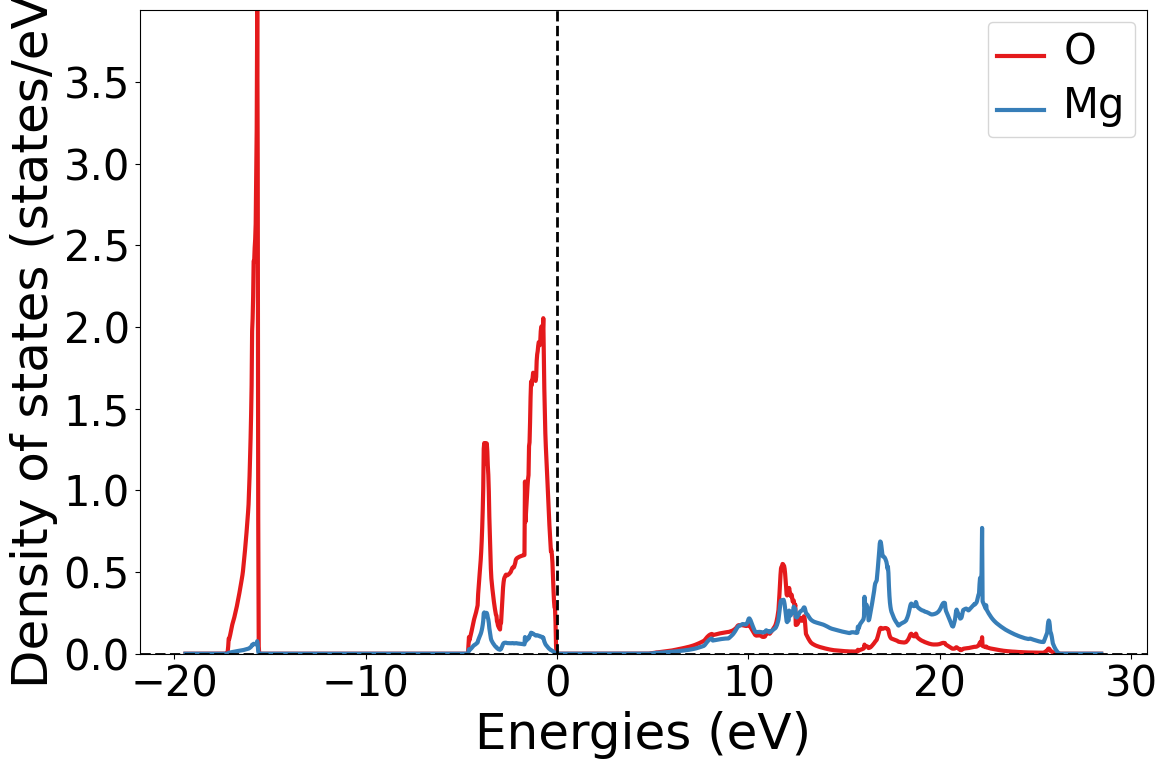

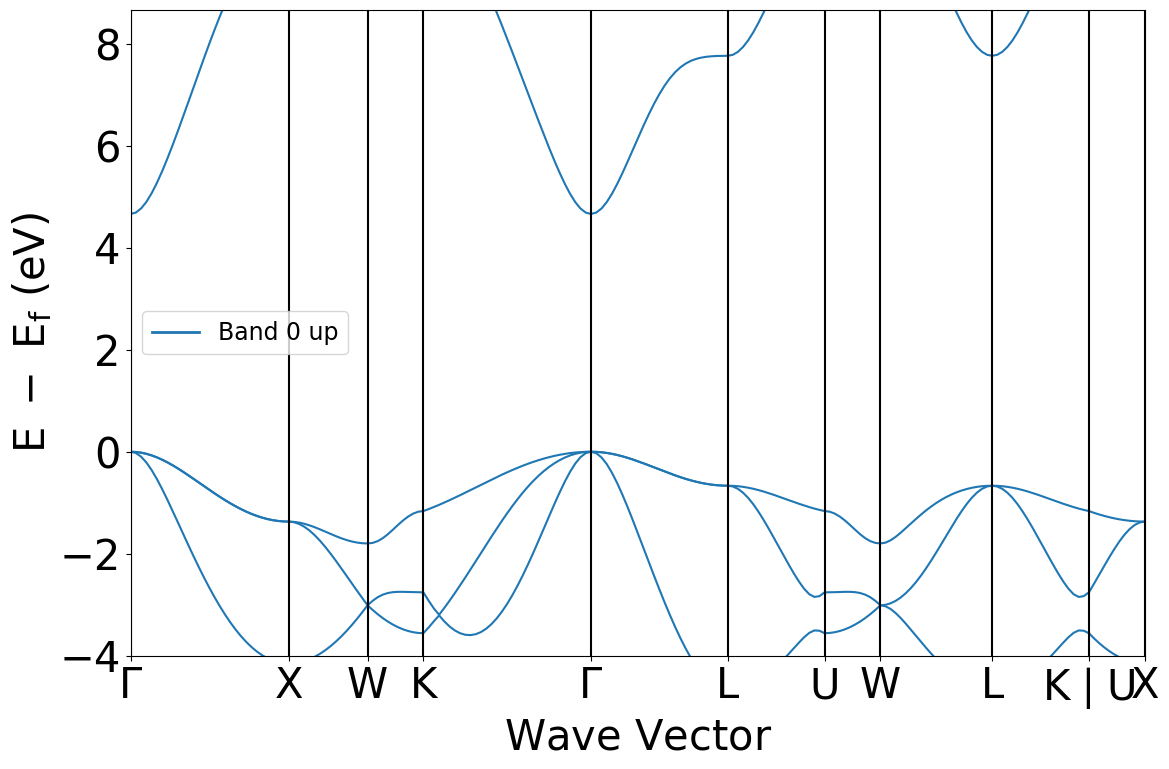

In [8]:
# get the uniform bandstructure from the database
result = store.query_one(
    {"output.task_label": "non-scf uniform"},
    properties=["output.vasp_objects.dos"],
    load=True,  # DOS stored in the data store, so we need to explicitly load it
)
dos = CompleteDos.from_dict(result["output"]["vasp_objects"]["dos"])

# plot the DOS
dos_plotter = DosPlotter()
dos_plotter.add_dos_dict(dos.get_element_dos())
dos_plotter.show()

# get the line mode bandstructure from the database
result = store.query_one(
    {"output.task_label": "non-scf line"},
    properties=["output.vasp_objects.bandstructure"],
    load=True,  # BS stored in the data store, so we need to explicitly load it
)
bandstructure = BandStructureSymmLine.from_dict(
    result["output"]["vasp_objects"]["bandstructure"]
)

# plot the line mode band structure
bs_plotter = BSPlotter(bandstructure)
bs_plotter.show()

